Celda 1: Librerías e Importaciones

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, classification_report

# Configurar el dispositivo (CPU o GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Trabajando en: {device}")

Trabajando en: cpu


Celda 2: La Clase Proyectora (Dataset)

In [12]:
class DatasetParcial(Dataset):
    def __init__(self, file_path):
        # Leer reconociendo "?" como nulo y quitando espacios
        df = pd.read_csv(file_path, header=None, na_values="?", skipinitialspace=True)
        
        # Separar tipos de columnas
        cols_num = df.select_dtypes(include=[np.number]).columns
        cols_cat = df.select_dtypes(exclude=[np.number]).columns

        # IMPUTACIÓN: Rellenar nulos
        if not cols_num.empty:
            df[cols_num] = SimpleImputer(strategy='mean').fit_transform(df[cols_num])
        if not cols_cat.empty:
            df[cols_cat] = SimpleImputer(strategy='most_frequent').fit_transform(df[cols_cat])

        # CODIFICACIÓN: Texto a Números
        for col in cols_cat:
            df[col] = LabelEncoder().fit_transform(df[col].astype(str))

        # Tensores y Escalado
        X_raw = df.iloc[:, :-1].values.astype(np.float32)
        y_raw = df.iloc[:, -1].values.astype(np.int64)

        self.scaler = StandardScaler()
        self.X = torch.from_numpy(self.scaler.fit_transform(X_raw))
        self.y = torch.from_numpy(y_raw)

    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

# Arquitectura de la Red Neuronal
class RedIA(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 2)
        )
    def forward(self, x): return self.net(x)

Celda 3: Definición de la Red Neuronal

In [7]:
class RedNeuronales(nn.Module):
    def __init__(self, input_size, num_classes):
        super(RedNeuronales, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.layers(x)

Celda 4: Carga y Entrenamiento de CREDIT (CRX)

In [14]:
import os
import pandas as pd
import numpy as np
import torch

# Ruta ultra simplificada
ruta_crx = r"C:\datos\crx.data"

if os.path.exists(ruta_crx):
    ds_crx = DatasetParcial(ruta_crx)
    
    # Pesos automáticos
    cl_crx, co_crx = np.unique(ds_crx.y.numpy(), return_counts=True)
    pesos_crx = torch.tensor(1.0 / (co_crx / co_crx.sum())).to(device).float() # Forzamos float aquí
    pesos_crx = pesos_crx / pesos_crx.sum()
    
    # Modelo y Entrenamiento
    model_crx = RedIA(ds_crx.X.shape[1]).to(device)
    crit_crx = nn.CrossEntropyLoss(weight=pesos_crx)
    opt_crx = optim.Adam(model_crx.parameters(), lr=0.001)
    load_crx = DataLoader(ds_crx, batch_size=32, shuffle=True)
    
    model_crx.train()
    for e in range(10):
        for xb, yb in load_crx:
            # .float() es la clave para evitar el error de Double
            xb, yb = xb.to(device).float(), yb.to(device)
            
            # Aquí es donde fallaba antes
            logits = model_crx(xb) 
            loss = crit_crx(logits, yb)
            
            opt_crx.zero_grad()
            loss.backward()
            opt_crx.step()
            
    print("✅ Modelo de Crédito Entrenado con éxito")
else:
    print(f"❌ Falta crx.data en {ruta_crx}")

✅ Modelo de Crédito Entrenado con éxito


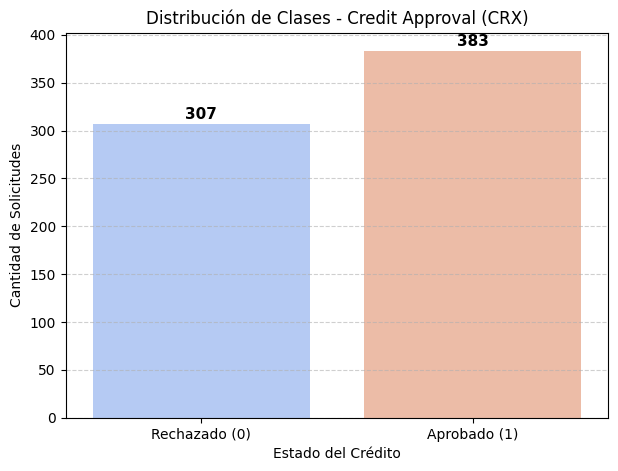

Clase 0: 307 (44.49%)
Clase 1: 383 (55.51%)


In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extraer las etiquetas (y) del dataset de crédito
y_crx_np = ds_crx.y.numpy()

# 2. Contar cuántos hay de cada clase
clases_crx, conteos_crx = np.unique(y_crx_np, return_counts=True)

# 3. Crear la gráfica
plt.figure(figsize=(7, 5))
# Usamos una paleta distinta para diferenciarlo del de Adult
sns.barplot(x=clases_crx, y=conteos_crx, palette='coolwarm', hue=clases_crx, legend=False)

# 4. Personalizar etiquetas (En CRX: 0 suele ser rechazo '-' y 1 es aprobación '+')
plt.xticks(ticks=[0, 1], labels=['Rechazado (0)', 'Aprobado (1)'])
plt.title('Distribución de Clases - Credit Approval (CRX)')
plt.xlabel('Estado del Crédito')
plt.ylabel('Cantidad de Solicitudes')

# Añadir los valores exactos encima de las barras
for i, v in enumerate(conteos_crx):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold', fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# Imprimir el porcentaje de desbalanceo para tu defensa
total = len(y_crx_np)
print(f"Clase 0: {conteos_crx[0]} ({conteos_crx[0]/total*100:.2f}%)")
print(f"Clase 1: {conteos_crx[1]} ({conteos_crx[1]/total*100:.2f}%)")

Celda 6: Evaluación y Matriz de Confusión 


--- REPORTE CREDIT APPROVAL ---
              precision    recall  f1-score   support

           0       0.85      0.90      0.88       307
           1       0.92      0.87      0.90       383

    accuracy                           0.89       690
   macro avg       0.89      0.89      0.89       690
weighted avg       0.89      0.89      0.89       690



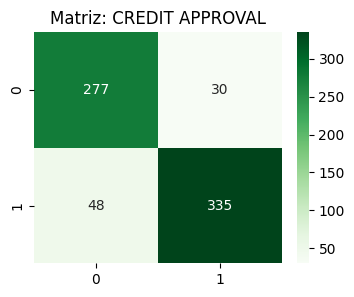

In [17]:
def evaluar(modelo, dataset, nombre):
    modelo.eval()
    with torch.no_grad():
        X = dataset.X.to(device)
        y_true = dataset.y.numpy()
        _, y_pred = torch.max(modelo(X), 1)
        y_pred = y_pred.cpu().numpy()
    
    print(f"\n--- REPORTE {nombre} ---")
    print(classification_report(y_true, y_pred))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
    plt.title(f'Matriz: {nombre}')
    plt.show()
evaluar(model_crx, ds_crx, "CREDIT APPROVAL")